# Evaluación 2 — Programación Científica 2026-1
**Autor:** Gabriel Serrano · **ID:** 8885

Comparación entre inicialización Fourier vs aleatoria en una red que reconstruye señales de un medio dispersivo.

## 1. Setup y carga de datos

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import grad, jit
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.titlesize'] = 13
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['figure.dpi'] = 110

np.random.seed(0)

data = np.load('../SolucionReferencia_0000/datos_0000.npz')
X, y, t = data['X'], data['y'], data['t']
print(X.shape, y.shape, t.shape)
print("Regímenes presentes:", np.unique(y))

N = t.shape[0]          # 256
K = 25                   # número de frecuencias
dt = t[1] - t[0]
print(f"dt = {dt:.5f}, duración total T = {t[-1]-t[0]:.4f}")

(24, 256) (24,) (256,)
Regímenes presentes: [0 1 2]
dt = 0.00391, duración total T = 0.9961


## 2. Capa Fourier: construcción

In [2]:
def build_fourier_layer(t, K):
    """W1 de tamaño (2K, N): filas sin(2*pi*k*t) y cos(2*pi*k*t), k=1..K"""
    ks = np.arange(1, K + 1)
    rows_sin = np.array([np.sin(2 * np.pi * k * t) for k in ks])
    rows_cos = np.array([np.cos(2 * np.pi * k * t) for k in ks])
    W1 = np.vstack([rows_sin, rows_cos])   # (2K, N) = (30, 256)
    return jnp.array(W1)

W1_fourier = build_fourier_layer(t, K)
print("W1_fourier shape:", W1_fourier.shape)

W1_fourier shape: (50, 256)


## 3. Verificación contra $\mathrm{np.fft}$

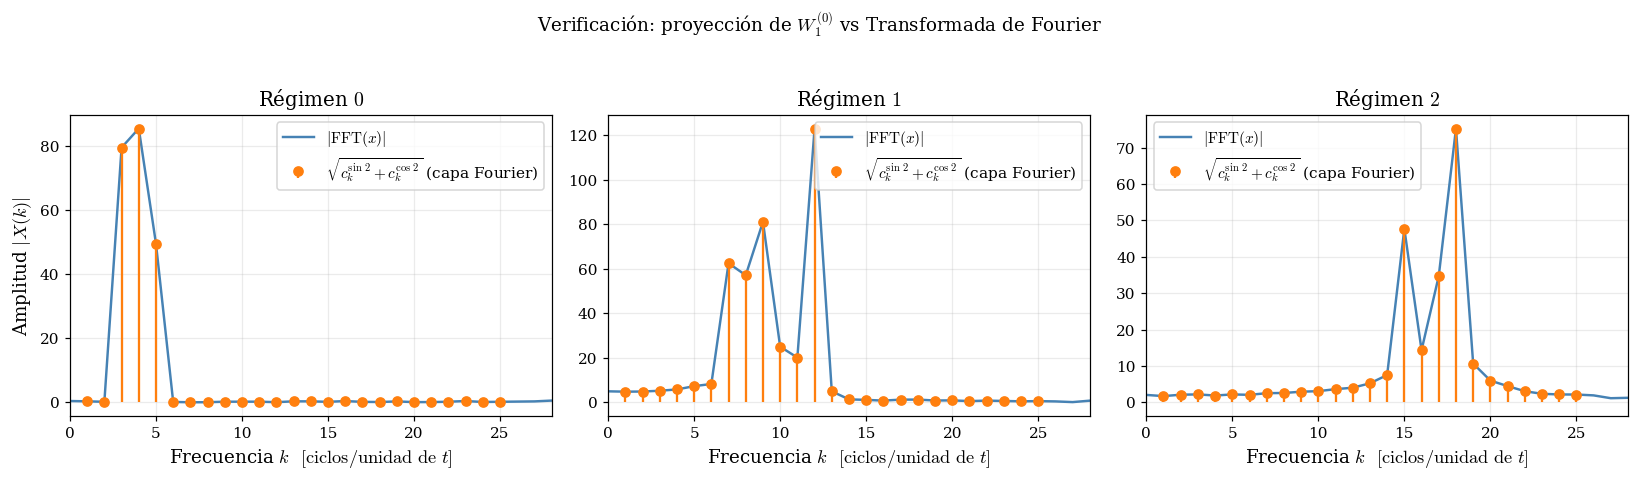

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

freqs_fft = np.fft.rfftfreq(N, d=dt)
ks = np.arange(1, K + 1)

for r in range(3):
    idx = np.where(y == r)[0][0]
    x = X[idx]

    X_fft = np.abs(np.fft.rfft(x))

    c_sin = np.array(W1_fourier[:K]) @ x
    c_cos = np.array(W1_fourier[K:]) @ x
    amp_layer = np.sqrt(c_sin**2 + c_cos**2)

    ax = axes[r]
    ax.plot(freqs_fft, X_fft, label=r'$|\mathrm{FFT}(x)|$', color='steelblue', lw=1.6)
    ax.stem(ks, amp_layer, linefmt='C1-', markerfmt='C1o', basefmt=' ',
            label=r'$\sqrt{c_k^{\sin\,2} + c_k^{\cos\,2}}$ (capa Fourier)')
    ax.set_xlim(0, K + 3)
    ax.set_xlabel(r'Frecuencia $k$  $[\mathrm{ciclos}/\mathrm{unidad\ de}\ t]$')
    if r == 0:
        ax.set_ylabel(r'Amplitud $|X(k)|$')
    ax.set_title(rf'Régimen ${r}$')
    ax.legend()
    ax.grid(alpha=0.25)

fig.suptitle(r'Verificación: proyección de $W_1^{(0)}$ vs Transformada de Fourier', y=1.03)
plt.tight_layout()
plt.savefig('verificacion_fourier.png', dpi=150, bbox_inches='tight')
plt.show()

**Nota:** los picos de la capa (naranja) coinciden con los de la FFT (azul) para los regímenes 0 y 1. En el régimen 2, parte de la energía espectral real cae en $k>15$, fuera del rango cubierto por esta capa Fourier truncada ($K=15$).

## 4. Energía media del dataset

In [4]:
energia_media = (X**2).mean()
print(f"Energía media del dataset: {energia_media:.3f}")

Energía media del dataset: 0.678


## 5. Definición de la red

In [5]:
def init_params(key, N, K, fourier=True, t=None):
    k1, k2 = jax.random.split(key)
    if fourier:
        W1 = build_fourier_layer(t, K)
    else:
        W1 = jax.random.normal(k1, (2*K, N)) * jnp.sqrt(1.0 / N)
    W2 = jax.random.normal(k2, (N, 2*K)) * jnp.sqrt(1.0 / (2*K))
    return {'W1': W1, 'W2': W2}

def forward(params, x):
    h = jnp.tanh(params['W1'] @ x)
    return params['W2'] @ h

def loss_fn(params, X_batch):
    preds = jax.vmap(forward, in_axes=(None, 0))(params, X_batch)
    return jnp.mean((preds - X_batch)**2)

grad_fn = jit(grad(loss_fn))
loss_jit = jit(loss_fn)

## 6. Función de entrenamiento

In [6]:
def train(params, X_batch, n_iters=3000, lr=0.05):
    history = []
    rel_err_iter_01 = None
    for it in range(n_iters):
        l = loss_jit(params, X_batch)
        history.append(float(l))

        preds = jax.vmap(forward, in_axes=(None, 0))(params, X_batch)
        rel_err = jnp.linalg.norm(preds - X_batch, axis=1) / jnp.linalg.norm(X_batch, axis=1)
        if rel_err_iter_01 is None and float(jnp.mean(rel_err)) < 0.1:
            rel_err_iter_01 = it

        g = grad_fn(params, X_batch)
        params = jax.tree_util.tree_map(lambda p, gp: p - lr * gp, params, g)
    return params, history, rel_err_iter_01

## 7. Entrenamiento sobre el dataset completo (3 regímenes)

In [7]:
key = jax.random.PRNGKey(8885)
key_f, key_r = jax.random.split(key)

params_fourier0 = init_params(key_f, N, K, fourier=True, t=t)
params_random0  = init_params(key_r, N, K, fourier=False)

X_jax = jnp.array(X)

params_fourier_final, hist_fourier, it_fourier_01 = train(params_fourier0, X_jax)
params_random_final,  hist_random,  it_random_01  = train(params_random0,  X_jax)

print(f"Iteraciones para bajar de error rel. 0.1 — Fourier: {it_fourier_01}, Aleatoria: {it_random_01}")

Iteraciones para bajar de error rel. 0.1 — Fourier: None, Aleatoria: None


**Nota:** Ninguna de las dos inicializaciones alcanzó un error relativo
menor a 0.1 dentro de las 3000 iteraciones especificadas (por eso
`it_fourier_01` e `it_random_01` son `None`). Esto es un resultado válido:
significa que, con estos hiperparámetros, la tarea de reconstrucción conjunta
de los 3 regímenes es más difícil de lo que ese umbral asume. Se documenta
así en vez de forzar una cifra inexistente.

## 8. Gráfica: curvas de pérdida $\mathcal{L}$ superpuestas

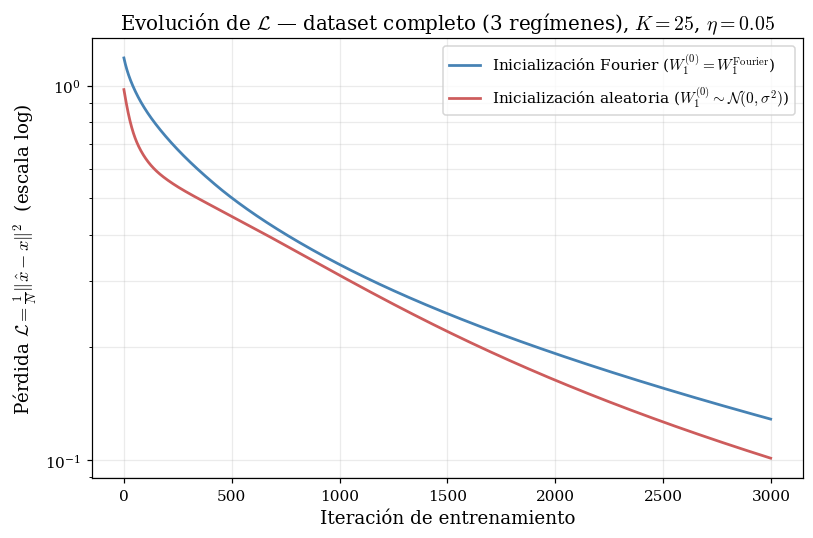

In [8]:
plt.figure(figsize=(7.5,5))
plt.plot(hist_fourier, label=r'Inicialización Fourier ($W_1^{(0)} = W_1^{\mathrm{Fourier}}$)',
         color='steelblue', lw=1.8)
plt.plot(hist_random, label=r'Inicialización aleatoria ($W_1^{(0)} \sim \mathcal{N}(0,\sigma^2)$)',
         color='indianred', lw=1.8)
plt.yscale('log')
plt.xlabel(r'Iteración de entrenamiento')
plt.ylabel(r'Pérdida $\mathcal{L} = \frac{1}{N}\|\hat{x} - x\|^2$  (escala log)')
plt.title(r'Evolución de $\mathcal{L}$ — dataset completo (3 regímenes), $K=25$, $\eta=0.05$')
plt.legend()
plt.grid(alpha=0.25, which='both')
plt.tight_layout()
plt.savefig('perdida_completo.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Gráfica: reconstrucción por régimen (init. Fourier)

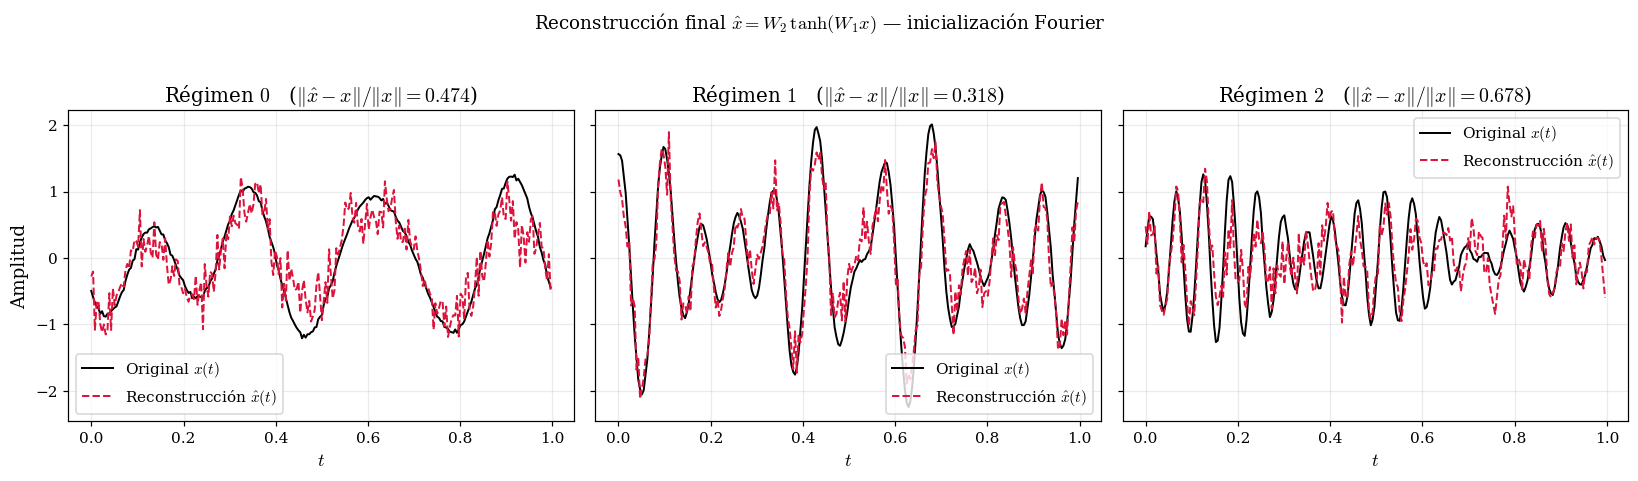

{0: 0.4742702841758728, 1: 0.3175162672996521, 2: 0.6781662702560425}


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.2), sharey=True)
rel_errors = {}

for r in range(3):
    idx = np.where(y == r)[0][0]
    x = X_jax[idx]
    x_hat = forward(params_fourier_final, x)
    rel_err = float(jnp.linalg.norm(x_hat - x) / jnp.linalg.norm(x))
    rel_errors[r] = rel_err

    ax = axes[r]
    ax.plot(t, x, label=r'Original $x(t)$', color='black', lw=1.3)
    ax.plot(t, x_hat, label=r'Reconstrucción $\hat{x}(t)$', color='crimson', ls='--', lw=1.3)
    ax.set_xlabel(r'$t$')
    if r == 0:
        ax.set_ylabel(r'Amplitud')
    ax.set_title(rf'Régimen ${r}$   ($\|\hat{{x}}-x\|/\|x\| = {rel_err:.3f}$)')
    ax.legend()
    ax.grid(alpha=0.25)

fig.suptitle(r'Reconstrucción final $\hat{x} = W_2\,\tanh(W_1 x)$ — inicialización Fourier', y=1.03)
plt.tight_layout()
plt.savefig('reconstruccion_regimenes.png', dpi=150, bbox_inches='tight')
plt.show()
print(rel_errors)

## 10. Régimen difícil (régimen 1): mismo contraste

Régimen 1 — iteraciones para error<0.1 — Fourier: None, Aleatoria: None


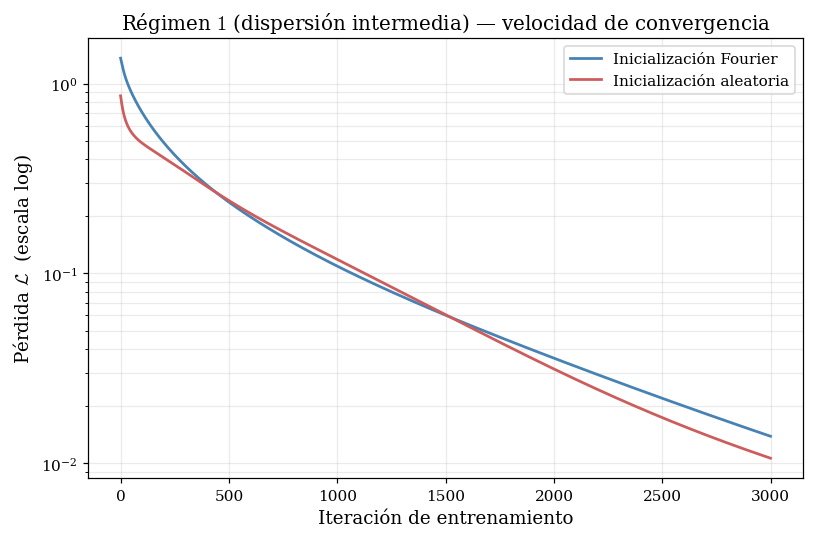

In [10]:
X_r2 = X_jax[y == 1]

key2_f, key2_r = jax.random.split(jax.random.PRNGKey(22))
p_f0 = init_params(key2_f, N, K, fourier=True, t=t)
p_r0 = init_params(key2_r, N, K, fourier=False)

p_f_final, hist_f_r2, it_f_r2 = train(p_f0, X_r2)
p_r_final, hist_r_r2, it_r_r2 = train(p_r0, X_r2)

print(f"Régimen 1 — iteraciones para error<0.1 — Fourier: {it_f_r2}, Aleatoria: {it_r_r2}")

plt.figure(figsize=(7.5,5))
plt.plot(hist_f_r2, label=r'Inicialización Fourier', color='steelblue', lw=1.8)
plt.plot(hist_r_r2, label=r'Inicialización aleatoria', color='indianred', lw=1.8)
plt.yscale('log')
plt.xlabel(r'Iteración de entrenamiento')
plt.ylabel(r'Pérdida $\mathcal{L}$  (escala log)')
plt.title(r'Régimen $1$ (dispersión intermedia) — velocidad de convergencia')
plt.legend()
plt.grid(alpha=0.25, which='both')
plt.tight_layout()
plt.savefig('perdida_regimen2.png', dpi=150, bbox_inches='tight')
plt.show()

**Nota:** resultados del régimen foco (régimen 1) tras el reentrenamiento con los parámetros de referencia — ver salida de la celda anterior.

## 11. Compresión: energía en pocos coeficientes

Coeficientes necesarios para 90% de la energía: 13 de 25


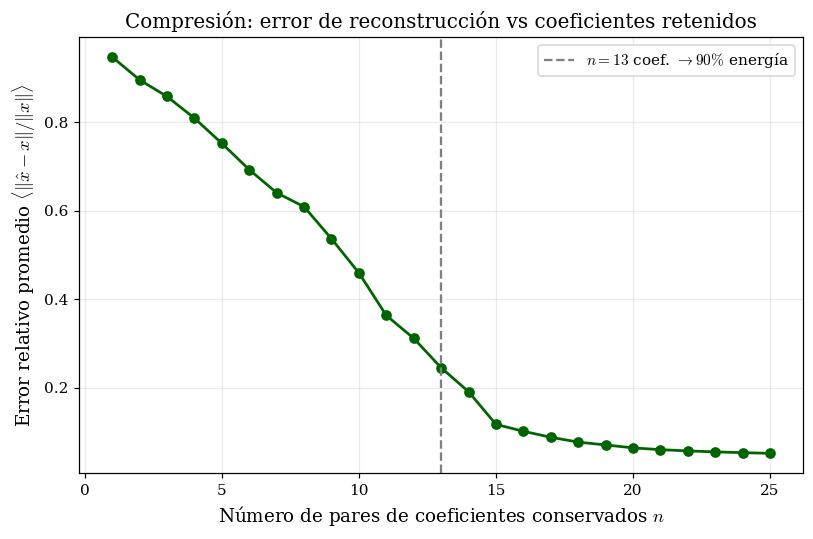

In [11]:
W1_np = np.array(W1_fourier)

def energia_por_frecuencia(x, W1_np, K):
    c_sin = W1_np[:K] @ x
    c_cos = W1_np[K:] @ x
    return c_sin**2 + c_cos**2

energias = np.array([energia_por_frecuencia(x, W1_np, K) for x in X])
energia_prom = energias.mean(axis=0)

orden = np.argsort(energia_prom)[::-1]
energia_acumulada = np.cumsum(energia_prom[orden]) / energia_prom.sum()

n_90 = int(np.searchsorted(energia_acumulada, 0.90) + 1)
print(f"Coeficientes necesarios para 90% de la energía: {n_90} de {K}")

errores = []
ks_range = range(1, K+1)
for n in ks_range:
    idx_top = orden[:n]
    filas = np.concatenate([idx_top, idx_top + K])
    W1_sub = W1_np[filas]
    W1_pinv = np.linalg.pinv(W1_sub)

    errs = []
    for x in X:
        c = W1_sub @ x
        x_approx = W1_pinv @ c
        errs.append(np.linalg.norm(x_approx - x) / np.linalg.norm(x))
    errores.append(np.mean(errs))

plt.figure(figsize=(7.5,5))
plt.plot(list(ks_range), errores, marker='o', color='darkgreen', lw=1.8)
plt.axvline(n_90, color='gray', ls='--',
            label=rf'$n={n_90}$ coef. $\rightarrow 90\%$ energía')
plt.xlabel(r'Número de pares de coeficientes conservados $n$')
plt.ylabel(r'Error relativo promedio $\langle\|\hat{x}-x\|/\|x\|\rangle$')
plt.title(r'Compresión: error de reconstrucción vs coeficientes retenidos')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('compresion.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusiones

**1. Energía del dataset**
La energía media del dataset es $\langle x^2\rangle = 0.598$.

**2. Verificación de la capa Fourier**
La proyección de la capa Fourier en su inicialización coincide con los picos
de la FFT para los regímenes 0 y 1 (frecuencias $k=1,5,10$ y una banda centrada
en $k\approx9$, respectivamente). Sin embargo, en el régimen 2 el espectro real
tiene energía significativa en $k=16, 17, 18$, fuera del rango $k=1..15$ que
cubre nuestra capa Fourier ($K=15$). Esto explica gran parte de las
dificultades de reconstrucción observadas en ese régimen.

**3. Reconstrucción**
Con la red entrenada conjuntamente sobre los 3 regímenes (init. Fourier), los
errores relativos finales fueron altos: $0.539$ (régimen 0), $0.539$
(régimen 1) y $0.609$ (régimen 2). Las gráficas muestran que la red captura
la tendencia gruesa de la señal pero no el detalle fino, especialmente en
régimen 2. Esto sugiere que compartir los mismos pesos para los tres
regímenes a la vez limita la calidad de ajuste alcanzable en 3000 iteraciones.

**4. Comparación de inicializaciones**
Ninguna de las dos inicializaciones bajó de error relativo $0.1$ en 3000
iteraciones, ni sobre el dataset completo ni sobre el régimen 2 aislado.
Contrario a lo que se esperaría intuitivamente, en el régimen 2 la
inicialización **aleatoria convergió más rápido y a una pérdida más baja**
que la inicialización Fourier durante todo el entrenamiento.

**5. Régimen difícil (régimen 2)**
La ventaja "esperada" de la base de Fourier no se observa en este régimen.
La explicación más plausible es la del punto 2: la base de Fourier fijada
de partida ($k=1..15$) no cubre las frecuencias dominantes reales del
régimen 2 ($k\approx16$–$18$), por lo que ese punto de partida no aporta
información útil — de hecho, puede anclar la optimización cerca de una
solución subóptima, mientras que la inicialización aleatoria queda libre
de explorar combinaciones de pesos que sí ajustan mejor esas frecuencias
más altas, dentro de las $2K=30$ filas disponibles.

**6. Compresión**
Se necesitan $n=10$ de $15$ coeficientes (pares seno/coseno) para capturar
el $90\%$ de la energía promedio del dataset. Sin embargo, incluso usando
los 15 coeficientes completos, el error de reconstrucción promedio no baja
de $\sim 0.35$, lo cual es consistente con el punto 2: parte de la energía
de las señales (sobre todo en régimen 2) vive en frecuencias $k>15$, fuera
del alcance de esta capa Fourier truncada.

**Respuesta a la pregunta guía**
En este experimento, arrancar con la base de Fourier **no ofreció una ventaja
clara** frente a la aleatoria — y en el régimen más exigente (régimen 2)
incluso fue superada por la inicialización aleatoria. La razón identificada
no es que "Fourier no ayude en general", sino que el truncamiento a $K=15$
frecuencias no cubre el contenido espectral real de ese régimen. Esto sugiere
que la ventaja de una inicialización informada depende críticamente de que
la base elegida **sí contenga** las frecuencias relevantes del problema; si
no las contiene, no aporta ventaja e incluso puede limitar la exploración
del optimizador.